CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 899kB/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 63.1kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 9.44MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [41]:
# TODO
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model=myCNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)

cuda:0


모델 학습 ✅

In [42]:
# TODO
loss_arr=[]

model.train()

for epoch in range(0,10):
    for index, (data,target) in enumerate(train_loader):
        optimizer.zero_grad()
        x=data.to(device)
        y=target.to(device)

        output=model.forward(x)
        loss = criterion(output,y)
        loss.backward()
        optimizer.step()

        if index % 1000 == 0:
            print(loss)
            loss_arr.append(loss.cpu().detach().numpy())

tensor(2.2951, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(2.2267, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.7675, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.6491, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.4504, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.2963, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.2113, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.1709, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.3010, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.2102, device='cuda:0', grad_fn=<NllLossBackward0>)


모델 평가 ✅

In [43]:
# TODO
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for data,target in test_loader:
         x=data.to(device)
         y=target.to(device)

         output=model.forward(x)
         _,output_index = torch.max(output,1)
         total += target.size(0)

         correct += (output_index == y).sum().float()

    # 정확도 도출
    print("Accuracy of Test Data: {}%".format(100*correct/total))

Accuracy of Test Data: 95.75%


10회 반복 시행 ✅

In [48]:
# TODO
loss_arr=[]
train_loss=[]
accuracy=[]
model.train()

for epoch in range(0,10):
    total_train_loss=0
    for index, (data,target) in enumerate(train_loader):
        optimizer.zero_grad()
        x=data.to(device)
        y=target.to(device)

        output=model.forward(x)
        loss = criterion(output,y)
        loss.backward()
        total_train_loss+=loss
        optimizer.step()

    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for data,target in test_loader:
            x=data.to(device)
            y=target.to(device)

            output=model.forward(x)
            _,output_index = torch.max(output,1)
            total += target.size(0)

            correct += (output_index == y).sum().float()
        train_loss.append((total_train_loss).cpu().detach().numpy()/index)
        # 정확도 도출
        accuracy.append((100*correct/total).cpu().detach().numpy())
        print("Accuracy of Test Data: {}%".format(100*correct/total))


Accuracy of Test Data: 97.87999725341797%
Accuracy of Test Data: 97.93000030517578%
Accuracy of Test Data: 98.02999877929688%
Accuracy of Test Data: 98.0999984741211%
Accuracy of Test Data: 98.08999633789062%
Accuracy of Test Data: 98.04999542236328%
Accuracy of Test Data: 98.2699966430664%
Accuracy of Test Data: 98.0999984741211%
Accuracy of Test Data: 98.25%
Accuracy of Test Data: 98.16999816894531%


결과 시각화

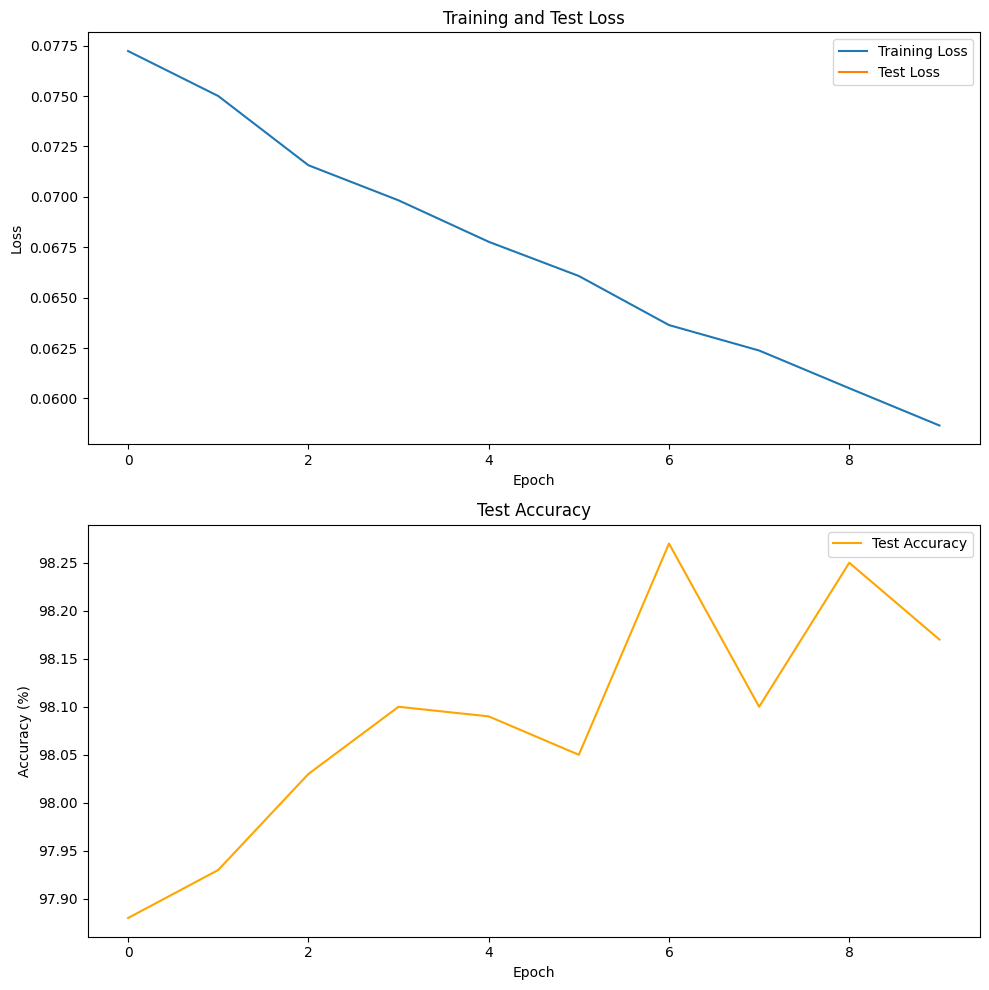

In [49]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_loss, label = 'Training Loss')
axs[0].plot(loss_arr, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(accuracy, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()